### Lab: Q-Learning to Solve the Cliff Walk Problem

### University of Virginia
### Reinforcement Learning
#### Last updated: June 26, 2026

---
#### Student: Pranav Sridhar
#### Computing ID: ps2pw
---

#### Instructions:

In Sutton & Barto (Section 6.5), the Cliff Walking problem is presented. You will apply Q-learning to teach an agent to solve it, following the instructions below carefully.  

Consider the grid below, where an agent begins in starting state S and wishes to reach goal state G by walking on a path and keeping off The Cliff (the gray region).  At each time step, the agent can potentially take one step left, right, up, or down. There is no discounting.  It is not possible for the agent to move off the grid. If the agent visits The Cliff, it incurs reward -100 and the episode terminates. The reward is -1 on all transitions apart from The Cliff. This incentivizes the agent to reach G as quickly as possible.

**Note**: Do not use libraries from `networkx`, `gym`, `gymnasium` when solving this problem.

---

<img src="./cliff_walk.png">  

#### TOTAL POINTS: 12

---

#### 1) Clearly explain how you will set up the state space and action space.
**(POINTS: 2)**

The state space is the set of all possible states the agent can be in. The action space is the set of all possible actions the agent can take in a given state. Hence, for the cliff walk problem, the action space will be {step left, step right, step up, step down}. The state space will be the following: (horizontal position coordinate, vertical position coordinate).

#### 2) Write a Q-learning algorithm that helps the agent learn a policy to reach the goal  
**(POINTS: 8)**.

Use $\epsilon$-greedy action selection with $\epsilon=0.1$.  
You can decide the other parameters as you wish.  

**Note to grader for partial credit:**  
Student answers in parts 3-5 should help understand if the algorithm is implemented correctly.  


In [22]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Initialize states, actions, Q function

# states
num_rows = 4
num_cols = 12
num_actions = 4 # 0=Up, 1=Down, 2=Left, 3=Right

start_state = (3, 0)
goal_state = (3, 11)
cliff_states = [(3, c) for c in range(1, 11)]

# initialize array to store action values Q
Q = np.random.normal(size=(num_rows, num_cols, num_actions))

def act(epsilon, action_values):
    '''
    epsilon-greedy policy: return action using epsilon-greedy strategy
    '''
    action_size = len(action_values)
    if np.random.rand() <= epsilon: # random draw with prob epsilon
        return random.randrange(action_size)
    return np.argmax(action_values)  # returns action

def determine_next_state(state, action):
    '''
    Accepts a (row, col) tuple and returns the next (row, col) tuple
    '''
    r, c = state
    
    if action == 0: # Up
        r = max(r - 1, 0)
    elif action == 1: # Down
        r = min(r + 1, num_rows - 1)
    elif action == 2: # Left
        c = max(c - 1, 0)
    elif action == 3: # Right
        c = min(c + 1, num_cols - 1)
        
    return (r, c)

def calc_reward(next_state):
    '''
    Returns reward based on the state transitioned into
    '''
    if next_state in cliff_states:
        return -100
    return -1

# Hyperparameters
num_episodes = 500
max_timesteps = 200
epsilon = 0.1
alpha = 0.5
gamma = 1.0

episode_outcomes = []

for ep in range(num_episodes):
    current_state = start_state
    done = False
    outcome = "Max Steps"
    
    for tm in range(max_timesteps):
        action = act(epsilon, Q[current_state])
        
        next_state = determine_next_state(current_state, action)
        reward = calc_reward(next_state)
        
        if next_state in cliff_states:
            done = True
            outcome = "Cliff"
        elif next_state == goal_state:
            done = True
            outcome = "Goal"
            
        target_max = 0 if done else np.amax(Q[next_state])
        Q[current_state][action] += alpha * (reward + gamma * target_max - Q[current_state][action])
        
        current_state = next_state
        
        if done:
            break
            
    episode_outcomes.append(outcome)

print("Training finished successfully with Tuple states!")

Training finished successfully with Tuple states!


#### 3) After training the policy, print the row from the Q-table representing the starting state  

In [23]:
start_q_values = Q[start_state]
action_names = ["Up", "Down", "Left", "Right"]

print(f"Q-values for Starting State {start_state}:")
for name, val in zip(action_names, start_q_values):
    print(f"  Action {name}: {val:0.3f}")

Q-values for Starting State (3, 0):
  Action Up: -13.000
  Action Down: -14.000
  Action Left: -13.999
  Action Right: -99.999


#### 4) Based on training results, create a plot that shows final state of each episode on the y-axis, and the episode number on the x-axis

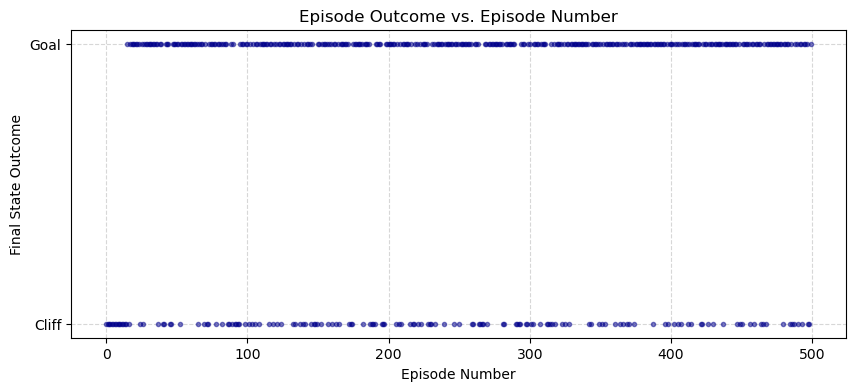

In [24]:
plt.figure(figsize=(10, 4))
plt.plot(episode_outcomes, '.', alpha=0.5, color='darkblue')
plt.title("Episode Outcome vs. Episode Number")
plt.xlabel("Episode Number")
plt.ylabel("Final State Outcome")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### 5) Given the learned policy, run one episode

Show evidence that the agent has learned how to successfully complete the Cliff walk

In [25]:
current_state = start_state
path_coordinates = [current_state]
done = False

while not done:
    action = np.argmax(Q[current_state])
    next_state = determine_next_state(current_state, action)
    
    path_coordinates.append(next_state)
    
    if next_state in cliff_states:
        print("Agent fell into the Cliff!")
        break
    elif next_state == goal_state:
        print("Agent successfully reached the Goal!")
        break
        
    current_state = next_state

print("Path traveled:", " -> ".join([str(coord) for coord in path_coordinates]))

Agent successfully reached the Goal!
Path traveled: (3, 0) -> (2, 0) -> (2, 1) -> (2, 2) -> (2, 3) -> (2, 4) -> (2, 5) -> (2, 6) -> (2, 7) -> (2, 8) -> (2, 9) -> (2, 10) -> (2, 11) -> (3, 11)


#### 6) Explain your results. Do they make sense?
**(POINTS: 2)**

**Note to grader for partial credit:** Grade based on the reasoning.

The results make sense and match how we would expect Q-Learning to perform for the Cliff Walking problem. The Q-value for moving up should be greater than moving right (which instantly drops it into the cliff and returns -100). Moving down or left bumps it into walls/environment boundaries, making going up the best action. 